In [ ]:
# Importing core data handling libraries
import pandas as pd
import numpy as np

# Importing visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# Suppressing warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Loading 2023 CSV dataset
df_2023 = pd.read_csv("TalentMatch AI Database_2023.csv")

In [ ]:
# Loading 2024 Excel dataset
df_2024 = pd.read_excel("TalentMatch AI Database_2024.xlsx")

In [ ]:
# Printing dataset shapes
print("2023 Shape:", df_2023.shape)
print("2024 Shape:", df_2024.shape)

2023 Shape: (1098, 16)
2024 Shape: (938, 16)


In [ ]:
# Printing the 2023 dataset columns
df_2023.columns

Index(['ID', 'Name', 'Gender', 'Age', 'Ethnicity', 'Country of Origin', 'Job',
       'Education Level', 'Years of Experience', 'Skills', 'AI Score',
       'Shortlisted', 'Branch Location', 'Application Date', 'Interview Date',
       'Team Name'],
      dtype='object')

In [ ]:
# Printing the 2024 dataset columns
df_2024.columns

Index(['ID', 'Name', 'Gender', 'Age', 'Ethnicity', 'Country of Origin', 'Job',
       'Education Level', 'Years of Experience', 'Skills', 'AI Score',
       'Shortlisted', 'Branch Location', 'Application Date', 'Interview Date',
       'Team Name'],
      dtype='object')

In [ ]:
# Combining both datasets
df = pd.concat([df_2023, df_2024], axis=0, ignore_index=True)

In [ ]:
# Setting ID column as index
df.set_index("ID", inplace=True)

In [ ]:
# Printing combined shape
print("Combined Dataset Shape:", df.shape)

Combined Dataset Shape: (2036, 15)


In [ ]:
# Printing combined data information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2036 entries, 1 to 2036
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 2036 non-null   object 
 1   Gender               2036 non-null   object 
 2   Age                  2036 non-null   int64  
 3   Ethnicity            2036 non-null   object 
 4   Country of Origin    2033 non-null   object 
 5   Job                  2036 non-null   object 
 6   Education Level      2036 non-null   object 
 7   Years of Experience  2036 non-null   int64  
 8   Skills               2036 non-null   object 
 9   AI Score             2036 non-null   float64
 10  Shortlisted          2036 non-null   bool   
 11  Branch Location      2036 non-null   object 
 12  Application Date     2036 non-null   object 
 13  Interview Date       2036 non-null   object 
 14  Team Name            2036 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(11

In [ ]:
# Displaying first few rows
df.head()

,Name,Gender,Age,Ethnicity,Country of Origin,Job,Education Level,Years of Experience,Skills,AI Score,Shortlisted,Branch Location,Application Date,Interview Date,Team Name
ID,,,,,,,,,,,,,,,
1,Avery Martin,M,37,Black or African American,Nigeria,Data Analyst,Bachelor,3,"Accounting, Decision Making, Adaptability, Dep...",2.0,True,Manchester,06/12/2023,28/12/2023,Charlie
2,Casey Anderson,F,39,Southeast Asian,Thailand,Accountant,Bachelor,0,"Accounting, Decision Making, Adaptability, Dep...",1.0,False,Manchester,09/06/2023,23/06/2023,Delta
3,Quinn Thomas,F,33,Southeast Asian,UK,Research Analyst,Master,0,"Creative problem solving, Critical thinking, D...",3.0,True,Bristol,21/04/2023,07/05/2023,Charlie
4,Morgan Johnson,M,60,Asian,China,Data Analyst,Bachelor,3,"Accounting, Data analysis, Decision Making, Ad...",3.0,True,Glasgow,02/05/2023,27/07/2023,Echo
5,Quinn Thomas,F,37,White,Germany,Creative Technologist,Master,4,"Coding, Graphic design, Data Visualisation, Ac...",5.0,True,Bristol,10/01/2023,06/02/2023,Alpha


In [ ]:
# Checking data types
df.dtypes

,0
Name,object
Gender,object
Age,int64
Ethnicity,object
Country of Origin,object
Job,object
Education Level,object
Years of Experience,int64
Skills,object
AI Score,float64


In [ ]:
# Converting Date columns to datetime
df["Application Date"] = pd.to_datetime(df["Application Date"], format="%d/%m/%Y")
df["Interview Date"] = pd.to_datetime(df["Interview Date"], format="%d/%m/%Y")

In [ ]:
# Checking duplicate IDs
duplicate_count = df.index.duplicated().sum()
print("Duplicate IDs Found:", duplicate_count)

Duplicate IDs Found: 0


In [ ]:
# Creating processing time feature
df["Processing_Days"] = (
    df["Interview Date"] - df["Application Date"]
).dt.days

In [ ]:
# Replacing zero age with NaN
df["Age"] = df["Age"].replace(0, np.nan)

In [ ]:
# Filling missing age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
# Filling missing country with 'Unknown'
df["Country of Origin"] = df["Country of Origin"].fillna("Unknown")

In [ ]:
# Converting AI Score to float
df["AI Score"] = df["AI Score"].astype(float)

In [ ]:
# Handling outliers using IQR method
numeric_cols = [
    "Age",
    "Years of Experience",
    "AI Score",
    "Processing_Days"]
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = len(df)

    # Removing outliers
    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

    after = len(df)

    print(f"{col}: Removed {before - after} outliers")

Age: Removed 0 outliers
Years of Experience: Removed 74 outliers
AI Score: Removed 26 outliers
Processing_Days: Removed 296 outliers


In [ ]:
# Analysing Key Descriptive Statistics
avg_age = df["Age"].mean()
avg_exp = df["Years of Experience"].mean()
avg_days = df["Processing_Days"].mean()

print("Average Age:", round(avg_age, 2))
print("Average Experience:", round(avg_exp, 2))
print("Average Processing Time (Days):", round(avg_days, 2))

Average Age: 39.58
Average Experience: 1.62
Average Processing Time (Days): 19.41


In [ ]:
# Checking for missing values after preprocessing
df.isnull().sum()

,0
Name,0
Gender,0
Age,0
Ethnicity,0
Country of Origin,0
Job,0
Education Level,0
Years of Experience,0
Skills,0
AI Score,0


In [ ]:
# Summarising the dataset
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,1640.0,39.576829,18.0,33.0,39.0,46.0,65.0,9.981995
Years of Experience,1640.0,1.619512,0.0,1.0,1.0,2.0,6.0,1.429783
AI Score,1640.0,2.220488,0.0,1.2,2.0,3.0,5.6,1.146763
Application Date,1640,2023-12-16 14:42:26.341463552,2023-01-01 00:00:00,2023-06-16 00:00:00,2023-12-05 00:00:00,2024-06-09 06:00:00,2024-12-30 00:00:00,NaN
Interview Date,1640,2024-01-05 00:30:43.902438912,2023-01-07 00:00:00,2023-07-05 18:00:00,2023-12-20 00:00:00,2024-07-02 06:00:00,2025-02-17 00:00:00,NaN
Processing_Days,1640.0,19.408537,1.0,10.0,18.0,26.0,57.0,12.265476


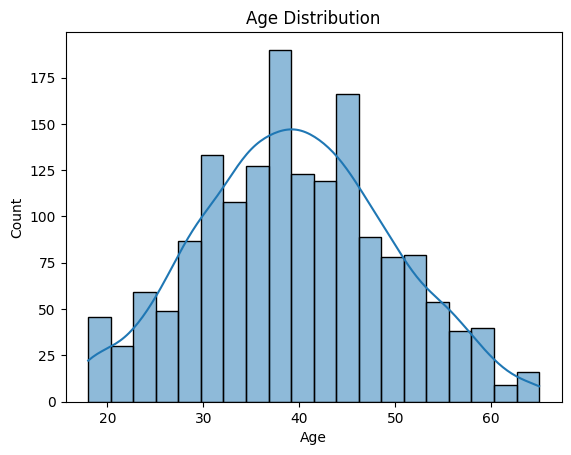

In [ ]:
# Plotting age distribution
plt.figure()
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

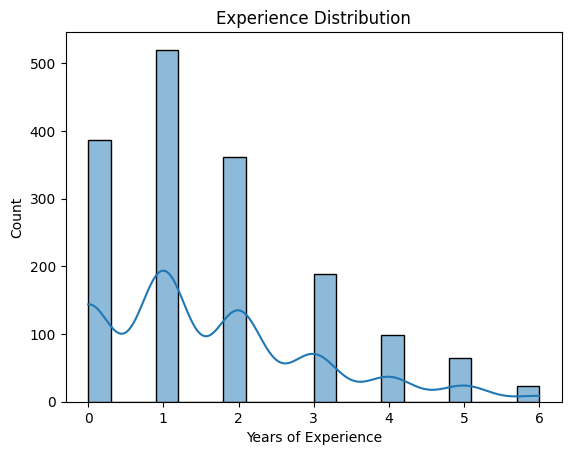

In [ ]:
# Plotting experience distribution
plt.figure()
sns.histplot(df["Years of Experience"], bins=20, kde=True)
plt.title("Experience Distribution")
plt.show()

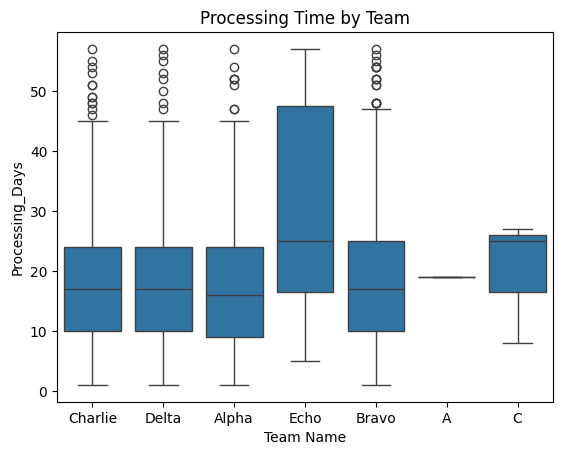

In [ ]:
# Plotting processing days by team
plt.figure()
sns.boxplot(x="Team Name", y="Processing_Days", data=df)
plt.title("Processing Time by Team")
plt.show()

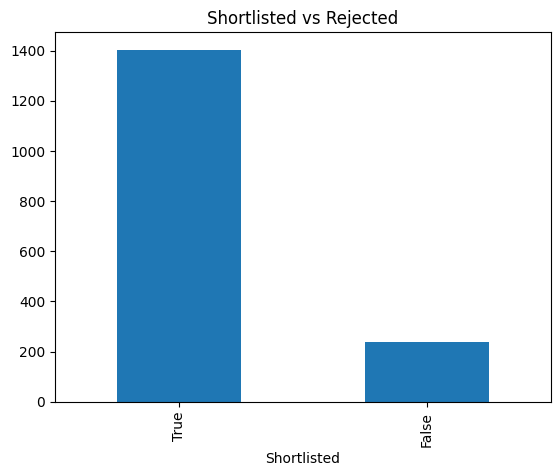

In [ ]:
# Counting shortlisted vs rejected
df["Shortlisted"].value_counts().plot(kind="bar")
plt.title("Shortlisted vs Rejected")
plt.show()

In [ ]:
# Displaying top 5 countries
df["Country of Origin"].value_counts().head(5)

,count
Country of Origin,
UK,491
Unknown,107
South Korea,100
Fiji,96
Iran,95


In [ ]:
# Creating gender shortlisting table
gender_bias = pd.crosstab(df["Gender"], df["Shortlisted"], normalize="index")
gender_bias

Shortlisted,False,True
Gender,,
F,0.139225,0.860775
M,0.149752,0.850248
Other,0.166667,0.833333


In [ ]:
# Creating ethnicity shortlisting table
ethnicity_bias = pd.crosstab(df["Ethnicity"], df["Shortlisted"], normalize="index")
ethnicity_bias

Shortlisted,False,True
Ethnicity,,
Asian,0.156522,0.843478
Black or African American,0.115385,0.884615
Central Asian,0.173913,0.826087
East Asian,0.196970,0.803030
Hispanic or Latino,0.119403,0.880597
Middle Eastern,0.157895,0.842105
Mixed,0.107692,0.892308
Native American,0.165217,0.834783
Other,0.148148,0.851852


In [ ]:
# Creating country shortlisting table
country_bias = pd.crosstab(df["Country of Origin"], df["Shortlisted"], normalize="index")
country_bias.head(10)

Shortlisted,False,True
Country of Origin,,
Brazil,0.162791,0.837209
China,0.227848,0.772152
Fiji,0.166667,0.833333
Germany,0.292683,0.707317
India,0.153846,0.846154
Iran,0.221053,0.778947
Kazakhstan,0.282353,0.717647
Mexico,0.177778,0.822222
Nigeria,0.148148,0.851852


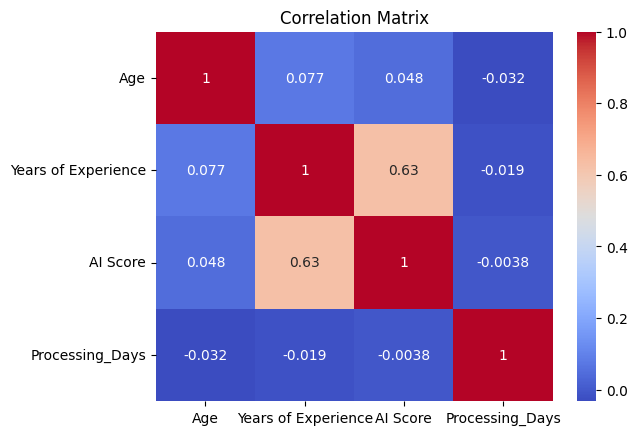

In [ ]:
# Plotting the correlation matrix
corr_matrix = df.select_dtypes(np.number).corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Selecting features
categorical_features = [
    "Gender", "Ethnicity", "Country of Origin",
    "Job", "Education Level",
    "Branch Location", "Team Name"]

numerical_features = [
    "Age",
    "Years of Experience",
    "AI Score",
    "Processing_Days"]

X = df[categorical_features + numerical_features]
y = df["Shortlisted"]

In [ ]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y)

In [ ]:
# Handling class imbalance using class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

In [ ]:
# Creating preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# Implementing logistic regression pipeling
log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict
    ))
])

In [ ]:
# Training logistic regression
log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Years of Experience',
                                                   'AI Score',
                                                   'Processing_Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Ethnicity',
                                                   'Country of Origin', 'Job',
                                                   'Education Level',
                                                   'Branch Location',
                                                   'Team Name'])])),
                ('classifier',
                 LogisticRegression(class_weight={np.False_: np.float64(3.455056179775281),
                                                  np.True_: np.float64(0.5846007604562737)},
                                    max_iter=1000))])

In [ ]:
# Predicting logistic regression
y_pred_log = log_pipeline.predict(X_test)

In [ ]:
# Evaluating logistic regression
print("Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
              precision    recall  f1-score   support

       False       0.76      1.00      0.86        59
        True       1.00      0.95      0.97       351

    accuracy                           0.95       410
   macro avg       0.88      0.97      0.92       410
weighted avg       0.96      0.95      0.96       410



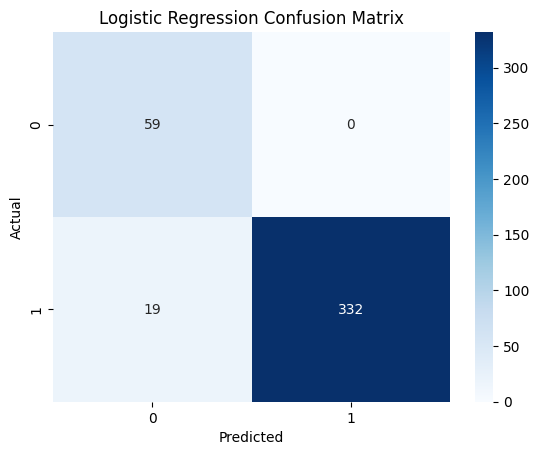

In [ ]:
# Plotting confusion matrix for Logistic Regression
LRcm = confusion_matrix(y_test, y_pred_log)
plt.figure()
sns.heatmap(LRcm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Implementing Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight=class_weight_dict
    ))
])

In [ ]:
# Training random forest
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Years of Experience',
                                                   'AI Score',
                                                   'Processing_Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Ethnicity',
                                                   'Country of Origin', 'Job',
                                                   'Education Level',
                                                   'Branch Location',
                                                   'Team Name'])])),
                ('classifier',
                 RandomForestClassifier(class_weight={np.False_: np.float64(3.455056179775281),
                                                      np.True_: np.float64(0.5846007604562737)},
                                        max_depth=10, n_estimators=200,
                                        random_state=42))])

In [ ]:
# Predicting random forest
y_pred_rf = rf_pipeline.predict(X_test)

In [ ]:
# Evaluating random forest
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

       False       0.88      1.00      0.94        59
        True       1.00      0.98      0.99       351

    accuracy                           0.98       410
   macro avg       0.94      0.99      0.96       410
weighted avg       0.98      0.98      0.98       410



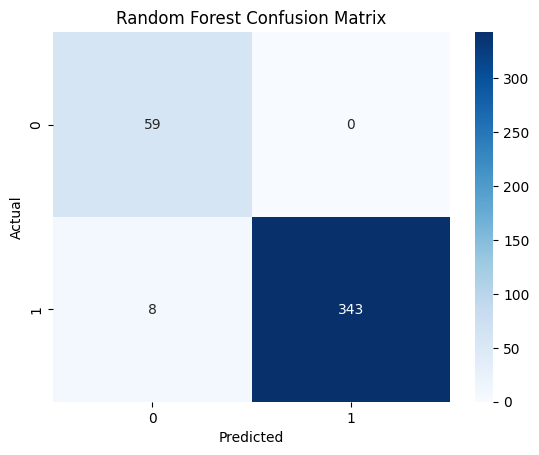

In [ ]:
# Plotting confusion matrix for random forest
RFcm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(RFcm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Calculating accuracies
acc_log = round(accuracy_score(y_test, y_pred_log)*100, 2)
acc_rf = round(accuracy_score(y_test, y_pred_rf)*100, 2)

In [ ]:
# Creating comparison dataframe
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_log, acc_rf]
})

In [ ]:
# Printing the comparison dataframe
results

,Model,Accuracy
0,Logistic Regression,95.37
1,Random Forest,98.05


In [ ]:
# Extracting feature importance
rf_model = rf_pipeline.named_steps["classifier"]
encoded_features = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features))
all_features = list(encoded_features) + numerical_features

In [ ]:
# Creating importance dataframe
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

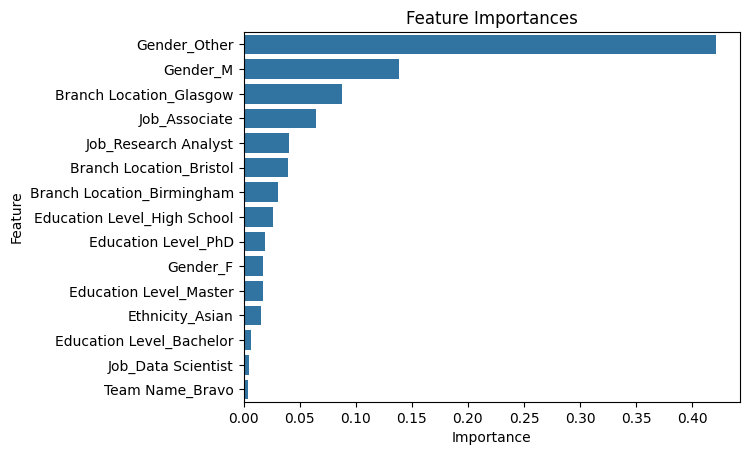

In [ ]:
# Plotting Feature Importances
plt.figure()
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(15))
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Exporting cleaned dataset
df.to_excel("Cleaned_TalentMatch_Data.xlsx", index=False)

In [ ]:
# Creating a summary dataframe
summary = pd.DataFrame({
    "Average Age": [df["Age"].mean()],
    "Average Experience": [df["Years of Experience"].mean()],
    "Shortlisted Count": [(df["Shortlisted"] == True).sum()],
    "Rejected Count": [(df["Shortlisted"] == False).sum()],
    "Average Processing Days": [df["Processing_Days"].mean()]
})

In [ ]:
# Exporting the Summary dataset
summary.to_excel("Excel_Validation_Summary.xlsx", index=False)